In [52]:
import gmsh
import pyvista
import viskex
import dolfinx.fem.petsc
import dolfinx.geometry
from mpi4py import MPI
import numpy as np
import ufl
from petsc4py import PETSc
from matplotlib import pyplot as plt

pyvista.set_jupyter_backend("static")

# Mesh properties
SYMMETRY_X_TAG = 3

bdim    = 1
gdim    = 2
R1      = 12
R2      = 15

mesh_size_local     = 0.005
mesh_size_far       = 3.0
refinement_radius   = 15

element = ("Lagrange", 1, (gdim,))

# Material properties
E1  = 2.1e5
E2  = 1.0e5
nu1 = 0.3
nu2 = 0.25
F   = 227.0613 * 2
U   = 0.02

R_ast = 1 / (1/R1 + 1/R2)
E_ast = 1 / ((1 - nu1**2)/E1 + (1 - nu2**2)/E2)

a   = np.sqrt(4*F*R_ast / (np.pi * E_ast))
p0  = 2*F / (np.pi * a)

mu1     = E1 / 2 / (1 + nu1)
mu2     = E2 / 2 / (1 + nu2)
lmbda1  = E1 * nu1 / (1 + nu1) / (1 - 2 * nu1)
lmbda2  = E2 * nu2 / (1 + nu2) / (1 - 2 * nu2)

# Contact shape functions
N1 = lambda xi: (1 - xi)
N2 = lambda xi: xi

B1 = -1
B2 = 1

gauss_xi1   = 0.5 - 0.5 / np.sqrt(3.0)
gauss_xi2   = 0.5 + 0.5 / np.sqrt(3.0)
weight      = 0.5

contact_search_radius   = mesh_size_local * 20
contact_gap_tol         = 1e-8
penalty_eps             = 8e7

# Iteration tolerances
max_iter = 30
tol      = 1e-10

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Circle)
Info    : [ 40%] Meshing curve 3 (Line)
Info    : [ 60%] Meshing curve 4 (Circle)
Info    : [ 70%] Meshing curve 5 (Line)
Info    : [ 90%] Meshing curve 6 (Line)
Info    : Done meshing 1D (Wall 0.0370572s, CPU 0.035934s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0208136s, CPU 0.019458s)
Info    : 599 nodes 1200 elements


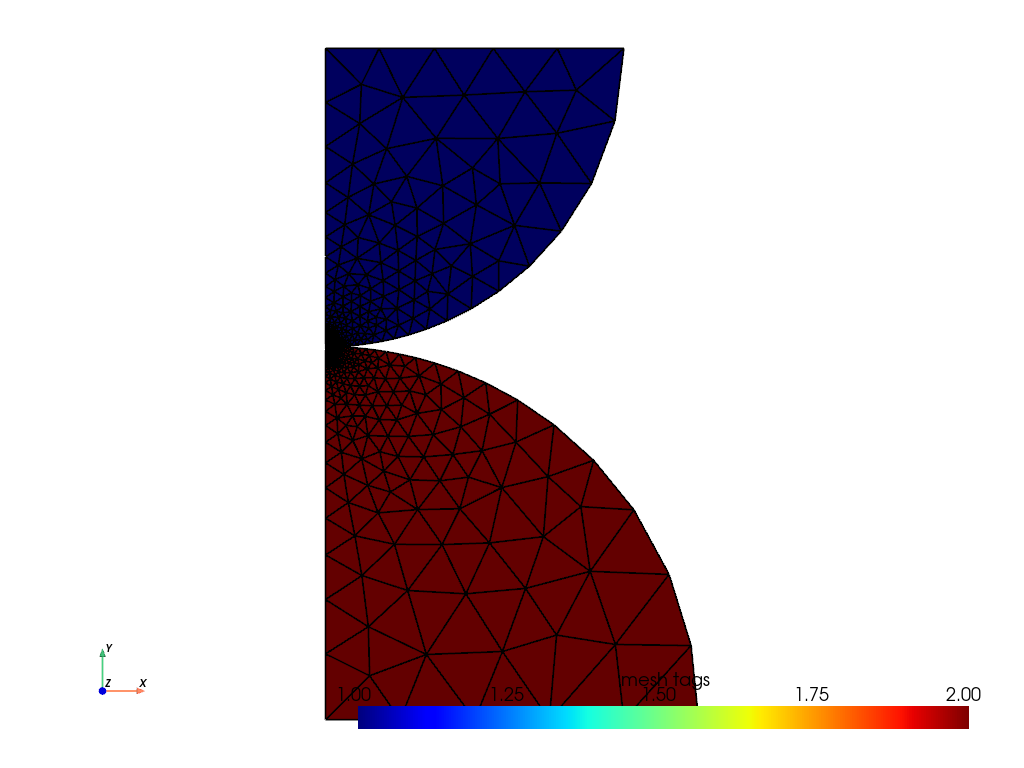

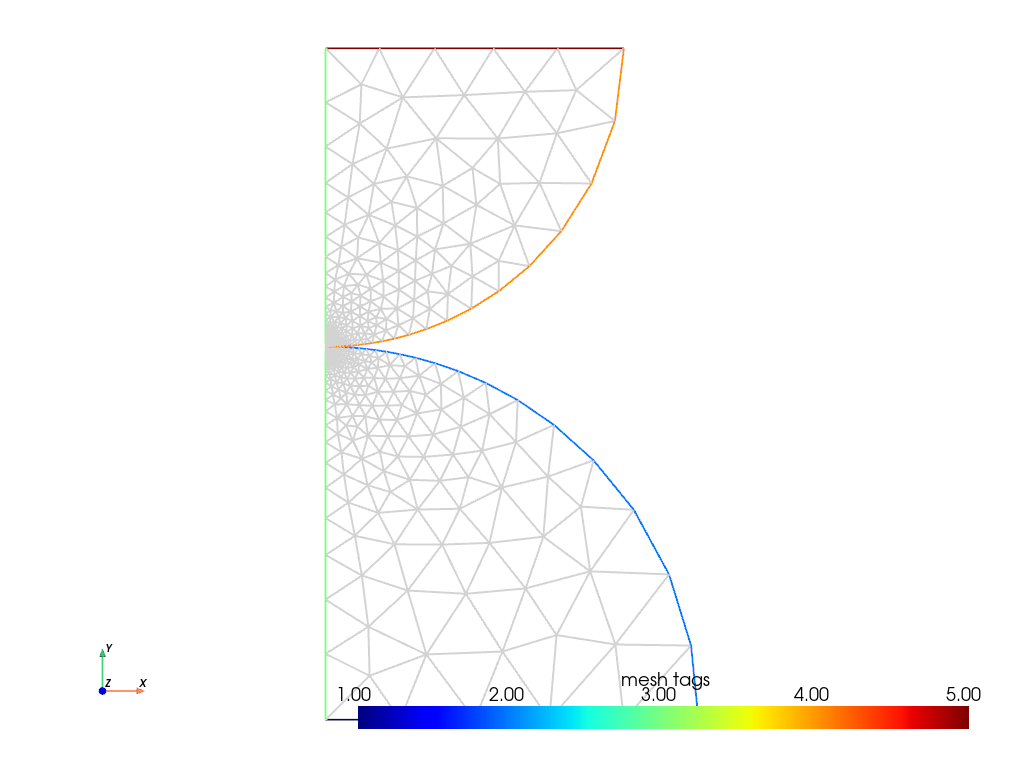

In [53]:
gmsh.initialize()
gmsh.model.add("hertz")

geo = gmsh.model.geo

p1 = geo.add_point(0, 0, 0)
p2 = geo.add_point(R2, 0, 0)
p3 = geo.add_point(0, R2, 0)
p4 = geo.add_point(0, R2, 0)
p5 = geo.add_point(R1, R1 + R2, 0)
p6 = geo.add_point(0, R1 + R2, 0)

l1 = geo.add_line(p1, p2)
l2 = geo.add_circle_arc(p2, p1, p3)
l3 = geo.add_line(p3, p1)

l4 = geo.add_circle_arc(p4, p6, p5)
l5 = geo.add_line(p5, p6)
l6 = geo.add_line(p6, p4)

cl1 = geo.add_curve_loop([l4, l5, l6])
cl2 = geo.add_curve_loop([l1, l2, l3])
s1  = geo.add_plane_surface([cl1])
s2  = geo.add_plane_surface([cl2])

geo.synchronize()

gmsh.model.add_physical_group(gdim, [s1], 1)
gmsh.model.add_physical_group(gdim, [s2], 2)
gmsh.model.add_physical_group(bdim, [l1], 1)
gmsh.model.add_physical_group(bdim, [l2], 2)
gmsh.model.add_physical_group(bdim, [l3, l6], SYMMETRY_X_TAG)
gmsh.model.add_physical_group(bdim, [l4], 4)
gmsh.model.add_physical_group(bdim, [l5], 5)

distance_field = gmsh.model.mesh.field.add("Distance")
gmsh.model.mesh.field.setNumbers(distance_field, "PointsList", [p3, p4])

threshold_field = gmsh.model.mesh.field.add("Threshold")
gmsh.model.mesh.field.setNumber(threshold_field, "InField", distance_field)
gmsh.model.mesh.field.setNumber(threshold_field, "SizeMin", mesh_size_local)
gmsh.model.mesh.field.setNumber(threshold_field, "SizeMax", mesh_size_far)
gmsh.model.mesh.field.setNumber(threshold_field, "DistMin", 0.0)
gmsh.model.mesh.field.setNumber(threshold_field, "DistMax", refinement_radius)
gmsh.model.mesh.field.setAsBackgroundMesh(threshold_field)

gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

gmsh.model.mesh.generate(2)
mesh_data = dolfinx.io.gmsh.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0, gdim)
gmsh.finalize()

domain      = mesh_data.mesh
cell_tags   = mesh_data.cell_tags
facet_tags  = mesh_data.facet_tags

tdim = domain.topology.dim
fdim = tdim - 1

top_facets      = facet_tags.find(5)
bottom_facets   = facet_tags.find(1)
slave_facets    = facet_tags.find(4)
master_facets   = facet_tags.find(2)

domain.topology.create_connectivity(fdim, tdim)
domain.topology.create_connectivity(tdim, 0)

facets2points = domain.topology.connectivity(fdim, 0)
facets2cells  = domain.topology.connectivity(fdim, tdim)
cells2points  = domain.topology.connectivity(tdim, 0)

viskex.dolfinx.plot_mesh_tags(domain, cell_tags)
viskex.dolfinx.plot_mesh_tags(domain, facet_tags)

Iteration   1, Residual 3.35e-01
Iteration   2, Residual 1.56e-01
Iteration   3, Residual 4.44e-03
Iteration   4, Residual 1.20e-02
Iteration   5, Residual 2.92e-03
Iteration   6, Residual 6.17e-03
Iteration   7, Residual 1.63e-03
Iteration   8, Residual 2.59e-03
Iteration   9, Residual 6.47e-04
Iteration  10, Residual 2.00e-04
Iteration  11, Residual 8.24e-16


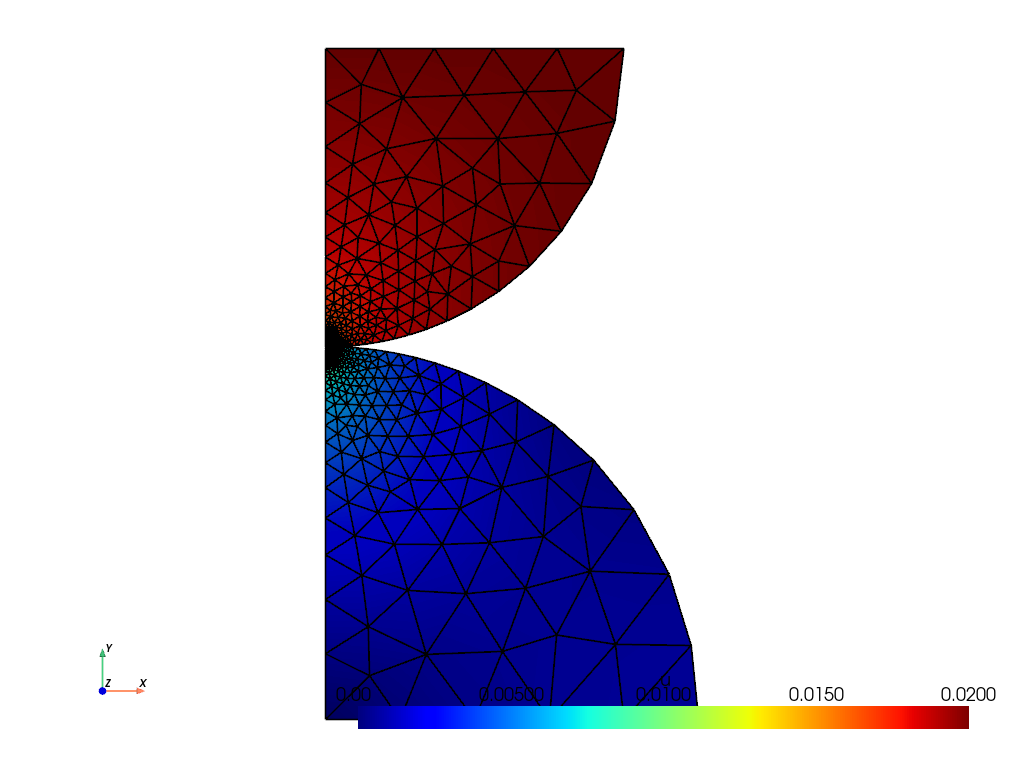

In [54]:
def eps(u):
    return ufl.sym(ufl.grad(u))

def sigma(u, mu, lmbda):
    return 2.0 * mu * eps(u) + lmbda * ufl.tr(eps(u)) * ufl.Identity(gdim)

dx = ufl.Measure("dx", domain=domain, subdomain_data=cell_tags)
ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)

V = dolfinx.fem.functionspace(domain, element)

bc_symmetry_x = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type(0.0),
    dolfinx.fem.locate_dofs_topological(V.sub(0), fdim, facet_tags.find(SYMMETRY_X_TAG)),
    V.sub(0),
)

bc_bottom = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type(0.0),
    dolfinx.fem.locate_dofs_topological(V.sub(1), fdim, bottom_facets),
    V.sub(1)
)

bc_top = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type(-U),
    dolfinx.fem.locate_dofs_topological(V.sub(1), fdim, top_facets),
    V.sub(1)
)

bcs = [bc_symmetry_x, bc_bottom, bc_top]

uh  = dolfinx.fem.Function(V)
du  = dolfinx.fem.Function(V)
v   = ufl.TestFunction(V)

elastic_residual = (ufl.inner(sigma(uh, mu1, lmbda1), eps(v)) * dx(1)
                    + ufl.inner(sigma(uh, mu2, lmbda2), eps(v)) * dx(2))
elastic_jacobian = ufl.derivative(elastic_residual, uh)

R_form = dolfinx.fem.form(elastic_residual)
J_form = dolfinx.fem.form(elastic_jacobian)

R = dolfinx.fem.petsc.create_vector(dolfinx.fem.extract_function_spaces(R_form))
A = dolfinx.fem.petsc.create_matrix(J_form)

bc_dofs = []
for bc in bcs:
    bc.set(uh.x.array)
    indices, unrolled = bc.dof_indices()
    bc_dofs.extend(indices)

bc_dofs = np.unique(bc_dofs).astype(np.int32)

master_tree = dolfinx.geometry.bb_tree(
    domain,
    fdim,
    padding=contact_search_radius,
    entities=master_facets,
)

def cell_midpoint_from_facet(segment):
    cells   = facets2cells.links(segment)
    points  = cells2points.links(cells[0])
    return np.mean(domain.geometry.x[points, :2], axis=0)

def segment_normal(segment, X11, X12):
    a = X12 - X11
    n = np.array([a[1], -a[0]], dtype=float)
    n /= np.linalg.norm(n)

    facet_mid = 0.5 * (X11 + X12)
    cell_mid  = cell_midpoint_from_facet(segment)

    if np.dot(n, cell_mid - facet_mid) > 0.0:
        n *= -1.0

    return n

def closest_segment(X1):

    best_segment  = None
    best_xi2      = None
    best_distance = np.inf
    query_point   = np.array([[X1[0], X1[1], 0.0]], dtype=domain.geometry.x.dtype)
    candidates    = dolfinx.geometry.compute_collisions_points(master_tree, query_point).links(0)

    for segment in candidates:

        points = facets2points.links(segment)
        p1     = points[0]
        p2     = points[1]

        X21 = domain.geometry.x[p1, :2]
        X22 = domain.geometry.x[p2, :2]

        a2  = B1 * X21 + B2 * X22
        xi2 = np.dot(X1 - X21, a2) / np.dot(a2, a2)

        if xi2 < 0.0 or xi2 > 1.0:
            continue

        X2       = N1(xi2) * X21 + N2(xi2) * X22
        distance = np.linalg.norm(X2 - X1)

        if distance > contact_search_radius:
            continue

        if distance < best_distance:
            best_segment  = segment
            best_xi2      = xi2
            best_distance = distance

    
    found = best_segment is not None
    return found, best_segment, best_xi2 

def assemble_point(A, R, uh, xi1):

    for segment in slave_facets:

        rows        = []
        u_local     = []

        # Slave
        points = facets2points.links(segment)
        p1     = points[0]
        p2     = points[1]

        dof1 = [p1 * 2, p1 * 2 + 1]
        dof2 = [p2 * 2, p2 * 2 + 1]
        rows.extend(dof1)
        rows.extend(dof2)

        X11 = domain.geometry.x[p1, :2]
        X12 = domain.geometry.x[p2, :2]

        u11 = uh.x.array[dof1]
        u12 = uh.x.array[dof2]
        u_local.extend(u11)
        u_local.extend(u12)

        X1 = N1(xi1) * X11 + N2(xi1) * X12
        u1 = N1(xi1) * u11 + N2(xi1) * u12
        a1 = B1 * X11 + B2 * X12

        # Master
        found, master_segment, xi2 = closest_segment(X1)

        # No contact
        if not found:
            continue

        points = facets2points.links(master_segment)
        p1     = points[0]
        p2     = points[1]

        dof1 = [p1 * 2, p1 * 2 + 1]
        dof2 = [p2 * 2, p2 * 2 + 1]
        rows.extend(dof1)
        rows.extend(dof2)

        X21 = domain.geometry.x[p1, :2]
        X22 = domain.geometry.x[p2, :2]

        u21 = uh.x.array[dof1]
        u22 = uh.x.array[dof2]
        u_local.extend(u21)
        u_local.extend(u22)

        X2 = N1(xi2) * X21 + N2(xi2) * X22
        u2 = N1(xi2) * u21 + N2(xi2) * u22
        n1 = segment_normal(segment, X11, X12)

        g_X = np.dot(X2 - X1, n1)
        g_N = np.dot(u2 - u1, n1) + g_X

        # No contact
        if g_N > 0 or g_X < -contact_gap_tol:
            continue

        N1_mat = np.zeros((2, 8))
        N1_mat[0, 0] = N1(xi1)
        N1_mat[1, 1] = N1(xi1)
        N1_mat[0, 2] = N2(xi1)
        N1_mat[1, 3] = N2(xi1)

        N2_mat = np.zeros((2, 8))
        N2_mat[0, 4] = N1(xi2)
        N2_mat[1, 5] = N1(xi2)
        N2_mat[0, 6] = N2(xi2)
        N2_mat[1, 7] = N2(xi2)

        n1      = n1.reshape(-1, 1)
        u_local = np.array(u_local).reshape(-1, 1)
        c       = (N2_mat - N1_mat).T @ n1

        Kc = weight * penalty_eps * np.linalg.norm(a1) * np.outer(c, c)
        FR = Kc @ u_local + weight * penalty_eps * np.linalg.norm(a1) * c * g_X

        R.setValues(rows, FR, addv=PETSc.InsertMode.ADD_VALUES)
        A.setValues(rows, rows, Kc, addv=PETSc.InsertMode.ADD_VALUES)

def assemble_contact(A, R, uh):

    assemble_point(A, R, uh, gauss_xi1)
    assemble_point(A, R, uh, gauss_xi2)


solver = PETSc.KSP().create(domain.comm)
solver.setOperators(A)
solver.setType("preonly")
solver.getPC().setType("lu")


for i in range(max_iter):

    with R.localForm() as loc_R:
        loc_R.set(0)
    A.zeroEntries()

    dolfinx.fem.petsc.assemble_matrix(A, J_form)
    dolfinx.fem.petsc.assemble_vector(R, R_form)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)

    assemble_contact(A, R, uh)

    A.assemble()
    R.assemble()

    A.zeroRowsColumns(bc_dofs, diag=1.0)

    rhs = R.copy()
    rhs.scale(-1.0)
    rhs.setValues(bc_dofs, np.zeros(bc_dofs.shape), addv=PETSc.InsertMode.INSERT_VALUES)
    rhs.assemble()

    du.x.array[:] = 0.0
    solver.setOperators(A)
    solver.solve(rhs, du.x.petsc_vec)

    residual = np.linalg.norm(du.x.array)
    uh.x.array[:] += du.x.array

    print(f"Iteration {i+1:3d}, Residual {residual:.2e}")

    if residual < tol:
        break

R.destroy()
A.destroy()
solver.destroy()

viskex.dolfinx.plot_vector_field(uh, name="u", warp_factor=1.0)

Ry = 227.0613 N/mm


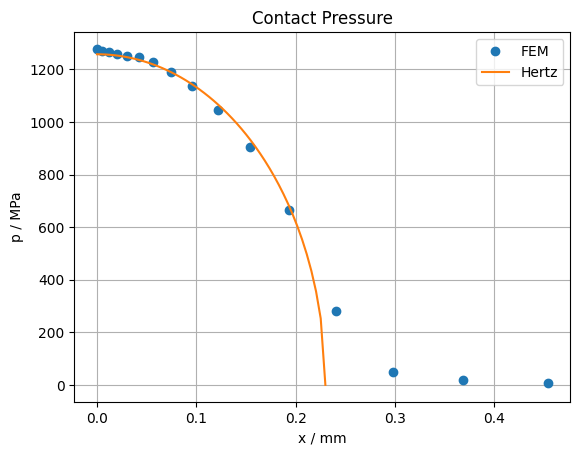

In [55]:
# Contact pressure
boundary_cells = np.array(
    [facets2cells.links(f) for f in slave_facets]).flatten()

boundary_nodes = np.unique(
    np.concatenate([facets2points.links(f) for f in slave_facets]))

x_mesh  = domain.geometry.x[boundary_nodes, 0]
Xm      = np.array([[1/3, 1/3]])
S       = dolfinx.fem.Expression(sigma(uh, mu1, lmbda1), Xm
            ).eval(domain, boundary_cells).reshape(-1, 2, 2)

values = np.zeros((len(domain.geometry.x), 2))

for facet, stress in zip(slave_facets, S):
    nodes = facets2points.links(facet)
    X1, X2 = domain.geometry.x[nodes, :2]

    length = np.linalg.norm(X2 - X1)
    normal = segment_normal(facet, X1, X2)
    sigma_nn = normal @ stress @ normal

    values[nodes, 0] += length * sigma_nn
    values[nodes, 1] += length

sigma_nn    = values[boundary_nodes, 0] / values[boundary_nodes, 1]
order       = np.argsort(x_mesh)
x_mesh      = x_mesh[order]
p_fem       = -sigma_nn[order]

x = np.linspace(0, a)
p = p0 * np.sqrt(1 - x**2 / a**2)

# Reaction force
n   = ufl.FacetNormal(domain)
Ry  = dolfinx.fem.assemble_scalar(
        dolfinx.fem.form(
            ufl.dot(sigma(uh, mu2, lmbda2), n)[1] * ds(1)
            )
        )


# Plot results
print(f"Ry = {Ry:.4f} N/mm")

plt.plot(x_mesh[x_mesh < 2*a], p_fem[x_mesh < 2*a], "o")
plt.plot(x, p)

plt.title("Contact Pressure")
plt.legend(["FEM", "Hertz"])
plt.xlabel("x / mm")
plt.ylabel("p / MPa")
plt.grid()
plt.show()